In [1]:
from app.utils.helper import extract_binary_to_json, read_file_as_binary
from app.utils.pdf_extractor.pdf_text_builder import PDFTextBuilder

In [2]:
from pathlib import Path
from typing import List, Optional, Tuple
import io
import fitz  # PyMuPDF

try:
    from PIL import Image  # only needed for JPEG encoding
    _HAS_PIL = True
except Exception:
    _HAS_PIL = False


def pdf_bytes_to_images(
    pdf_bytes: bytes,
    dpi: int = 200,
    fmt: str = "png",                   # "png" or "jpg"
    save_dir: Optional[Path | str] = None,
    base_filename: Optional[str] = None,  # used for saved filenames only
    jpg_quality: int = 90
) -> List[bytes]:
    """
    Render each page of a (scanned) PDF (given as bytes) to images and return a list of image bytes.
    Optionally save images to disk as <base_filename>_p<page>.<ext> (1-based page numbering).

    Args:
        pdf_bytes: Raw bytes of the PDF.
        dpi: Output DPI (controls resolution). 72 dpi == 1.0 zoom.
        fmt: "png" (native via PyMuPDF) or "jpg".
        save_dir: If provided, images are also saved to this directory.
        base_filename: If saving, the basename to use (default: "document").
        jpg_quality: JPEG quality (1–95) if fmt="jpg".

    Returns:
        List of bytes objects, one per page, in the requested format.
    """
    fmt = fmt.lower()
    if fmt not in {"png", "jpg", "jpeg"}:
        raise ValueError("fmt must be 'png' or 'jpg'")

    if fmt in {"jpg", "jpeg"} and not _HAS_PIL:
        raise RuntimeError("JPEG output requires Pillow (pip install Pillow)")

    # Prepare output directory (optional)
    out_dir: Optional[Path] = None
    if save_dir is not None:
        out_dir = Path(save_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        if not base_filename:
            base_filename = "document"

    if not base_filename:
        base_filename = "document"

    # DPI -> zoom factor
    zoom = dpi / 72.0
    mat = fitz.Matrix(zoom, zoom)

    images: List[bytes] = []

    # Open from bytes
    with fitz.open(stream=pdf_bytes, filetype="pdf") as doc:
        if doc.needs_pass:
            raise RuntimeError("This PDF is encrypted and needs a password.")
        page_count = doc.page_count

        for page_index, page in enumerate(doc, start=1):
            # Render to pixmap (no alpha for cleaner JPG/PNG)
            pix = page.get_pixmap(matrix=mat, alpha=False)

            if fmt == "png":
                img_bytes = pix.tobytes(output="png")  # PyMuPDF-native PNG
                ext = "png"
            else:
                # Convert Pixmap -> PIL Image -> JPEG bytes
                # pix.samples are RGB bytes; pix.stride is bytes per row
                mode = "RGB" if pix.n in (3, 4) else "L"
                pil_img = Image.frombytes(mode, (pix.width, pix.height), pix.samples)
                buf = io.BytesIO()
                pil_img.save(buf, format="JPEG", quality=jpg_quality, optimize=True)
                img_bytes = buf.getvalue()
                ext = "jpg"

            images.append(img_bytes)

            # Optional save
            if out_dir is not None:
                filename = f"{base_filename}_p{page_index}.{ext}"
                (out_dir / filename).write_bytes(img_bytes)

    return images


In [3]:
PATH = "root/20251112150947.pdf"
typ = "pdf"

file = read_file_as_binary(PATH)

In [4]:
imgs = pdf_bytes_to_images(
    file,
    dpi=400,
    fmt="png",
    save_dir="output",  # or None to skip saving
    base_filename="my_scan"           # filename prefix for saved files
)

print(f"Returned {len(imgs)} images as bytes.")

Returned 5 images as bytes.


In [5]:
import os
from typing import List, Dict, Any, Tuple

import cv2
import numpy as np


CropRatio = Tuple[float , float, float, float]  # ((xmin, ymin), (xmax, ymax))


def bytes_to_cv2_image(image_bytes: bytes) -> np.ndarray:
    """
    Convert raw image bytes to an OpenCV BGR image.
    """
    nparr = np.frombuffer(image_bytes, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError("Could not decode image bytes")
    return img


def slice_image_by_ratios(
    img: np.ndarray,
    crop_ratios: List[CropRatio],
    margin: float = 0.03,
) -> List[Dict[str, Any]]:
    """
    Slice an image according to a list of crop ratios.

    Each ratio is ((xmin, ymin), (xmax, ymax)), where:
      - xmin, ymin, xmax, ymax are in [0, 1]
      - (0,0) is top-left, (1,1) is bottom-right of the original image.

    Returns a list of:
      {
        "tile_img": np.ndarray,           # tile image (BGR)
        "tile_bbox": (x0, y0, x1, y1),    # global coords in original image (pixels)
        "index": int,                     # index in the crop_ratios list
        "ratio": ((xmin, ymin), (xmax, ymax)),
      }
    """
    H, W = img.shape[:2]
    tiles: List[Dict[str, Any]] = []

    for idx, (xmin, ymin, xmax, ymax) in enumerate(crop_ratios):
        # Convert ratios to pixel coordinates
        xmin = max(0.0, xmin - margin)
        ymin = max(0.0, ymin - margin)
        xmax = min(1.0, xmax + margin)
        ymax = min(1.0, ymax + margin)

        x0 = int(round(xmin * W))
        y0 = int(round(ymin * H))
        x1 = int(round(xmax * W))
        y1 = int(round(ymax * H))

        # Clamp to bounds
        x0 = max(0, min(x0, W))
        x1 = max(0, min(x1, W))
        y0 = max(0, min(y0, H))
        y1 = max(0, min(y1, H))

        # Skip invalid boxes
        if x1 <= x0 or y1 <= y0:
            continue

        tile = img[y0:y1, x0:x1].copy()
        tiles.append(
            {
                "tile_img": tile,
                "tile_bbox": (x0, y0, x1, y1),
                "index": idx,
                "ratio": ((xmin, ymin), (xmax, ymax)),
            }
        )

    return tiles


def save_sliced_tiles_from_bytes(
    image_bytes: bytes,
    output_dir: str,
    crop_ratios: List[CropRatio],
    *,
    base_name: str = "page",
    margin: float = 0.03,
) -> List[str]:
    """
    Read image from bytes, slice according to crop_ratios, and save them into output_dir.

    Args:
        image_bytes: raw image bytes
        output_dir: folder to save tiles
        crop_ratios: list of ((xmin, ymin), (xmax, ymax)) in [0,1] coordinates
        base_name: prefix for output filenames

    Returns:
        List of file paths of saved tiles.
    """
    os.makedirs(output_dir, exist_ok=True)

    img = bytes_to_cv2_image(image_bytes)
    tiles = slice_image_by_ratios(img, crop_ratios, margin=margin)

    saved_paths: List[str] = []

    for t in tiles:
        idx = t["index"]
        tile_img = t["tile_img"]

        # e.g. page_000.png, page_001.png, ...
        filename = f"{base_name}_{idx:03d}.png"
        out_path = os.path.join(output_dir, filename)
        cv2.imwrite(out_path, tile_img)
        saved_paths.append(out_path)

    return saved_paths


In [6]:
import cv2
import numpy as np
from typing import Tuple

# Bounding box type: (x_min, y_min, x_max, y_max)
BBox = Tuple[int, int, int, int]


def crop_image_array(img: np.ndarray, bbox: BBox, margin=0) -> np.ndarray:
    """
    Crop an image (NumPy array) using pixel coordinates.

    Args:
        img: HxWxC or HxW image (BGR if from cv2).
        bbox: (x_min, y_min, x_max, y_max) in *pixel coordinates*.

    Returns:
        Cropped image as NumPy array.
    """
    if img is None:
        raise ValueError("crop_image_array: img is None")

    h, w = img.shape[:2]
    x_min, y_min, x_max, y_max = bbox

    # Clamp to image bounds
    x_min = int(max(0, min(x_min-margin, w)))
    x_max = int(max(0, min(x_max+margin, w)))
    y_min = int(max(0, min(y_min-margin, h)))
    y_max = int(max(0, min(y_max+margin, h)))

    if x_max <= x_min or y_max <= y_min:
        raise ValueError(f"Invalid bbox after clamping: {bbox}")

    # NumPy slices: [y_min:y_max, x_min:x_max]
    crop = img[y_min:y_max, x_min:x_max].copy()
    return crop


def crop_image_file(
    input_path: str,
    bbox: BBox,
    margin=0,
    output_path: str = None,
) -> np.ndarray:
    """
    Load an image from disk, crop by pixel bbox, optionally save.

    Args:
        input_path: path to input image.
        bbox: (x_min, y_min, x_max, y_max) in pixels.
        output_path: where to save cropped image (if not None).

    Returns:
        Cropped image as NumPy array.
    """
    img = cv2.imread(input_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {input_path}")

    crop = crop_image_array(img, bbox, margin=margin)

    if output_path is not None:
        cv2.imwrite(output_path, crop)

    return crop

def image_array_to_png_bytes(img: np.ndarray) -> bytes:
    """
    Encode an OpenCV image (np.ndarray, BGR) as PNG bytes.
    """
    ok, buf = cv2.imencode(".png", img)
    if not ok:
        raise ValueError("Failed to encode image to PNG")
    return buf.tobytes()

In [7]:
import cv2
import numpy as np


def strengthen_table_lines(path_in: str, path_out: str,
                           gap_len: int = 20,
                           thickening: int = 2) -> None:
    """
    - Connect small gaps in horizontal/vertical table lines.
    - Make table lines slightly thicker/darker so the effect is visible.
    - Try hard not to touch text.

    Parameters
    ----------
    gap_len : int
        Max gap (in pixels) along a line that we will close.
        Increase if you still see tiny breaks.
    thickening : int
        Extra thickness (in pixels) for the table lines.
        1–3 is usually reasonable.
    """
    img = cv2.imread(path_in, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Cannot read image: {path_in}")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # binary: foreground (text+lines) = white, background = black
    _, bw = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    h, w = bw.shape

    # --- 1. extract long horizontal / vertical structures (table lines) -----
    horiz_len = max(w // 60, 25)   # tune if needed
    vert_len  = max(h // 60, 25)

    horiz_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (horiz_len, 1))
    vert_kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (1, vert_len))

    horiz_lines = cv2.morphologyEx(bw, cv2.MORPH_OPEN, horiz_kernel, iterations=1)
    vert_lines  = cv2.morphologyEx(bw, cv2.MORPH_OPEN, vert_kernel, iterations=1)

    table_mask = cv2.bitwise_or(horiz_lines, vert_lines)

    # --- 2. connect small gaps along these lines ---------------------------
    # only fill gaps up to `gap_len` pixels
    connect_h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (gap_len, 1))
    connect_v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, gap_len))

    connected_h = cv2.morphologyEx(horiz_lines, cv2.MORPH_CLOSE,
                                   connect_h_kernel, iterations=1)
    connected_v = cv2.morphologyEx(vert_lines, cv2.MORPH_CLOSE,
                                   connect_v_kernel, iterations=1)

    table_mask_connected = cv2.bitwise_or(connected_h, connected_v)

    # --- 3. protect text so we don't draw over characters ------------------
    no_table = cv2.subtract(bw, table_mask)  # foreground minus original table
    text_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    text_mask = cv2.dilate(no_table, text_kernel, iterations=1)

    # remove any pixels that overlap text from the table mask
    table_mask_safe = cv2.subtract(table_mask_connected, text_mask)

    # optional: slightly thicken table lines so they are clearly visible
    if thickening > 0:
        t_kernel = cv2.getStructuringElement(
            cv2.MORPH_RECT, (thickening, thickening)
        )
        table_mask_safe = cv2.dilate(table_mask_safe, t_kernel, iterations=1)

    # --- 4. draw those lines back onto the original image ------------------
    result = img.copy()
    ys, xs = np.where(table_mask_safe > 0)
    result[ys, xs] = (0, 0, 0)  # solid black lines

    cv2.imwrite(path_out, result)

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import hypot, atan2, degrees
from typing import List, Tuple, Dict, Set
import numpy as np

# ----------------- Types -----------------

Line = Tuple[Tuple[int, int], Tuple[int, int]]  # ((x1,y1),(x2,y2))
Line4 = Tuple[float, float, float, float]  # (x1, y1, x2, y2)


# ----------------- 1. Enhance faint lines -----------------

def enhance_lines(img: np.ndarray) -> np.ndarray:
    """
    Enhance faint table/grid lines in a scanned document.

    Returns a binary image (0/255) with lines & text in white.
    """
    if img is None:
        raise ValueError("enhance_lines: `img` is None")

    # BGR -> gray
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img.copy()

    # Local contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16, 16))
    cl = clahe.apply(gray)

    # Light blur
    blur = cv2.GaussianBlur(cl, (3, 3), 0)

    # Adaptive threshold (invert so lines/text become white)
    bw = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31,
        10,
    )

    # Close small gaps
    close_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    bw = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, close_kernel, iterations=1)

    # Slight dilation to thicken lines
    dil_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    bw = cv2.dilate(bw, dil_kernel, iterations=1)

    return bw


# ----------------- 2. Extract H/V lines from binary -----------------

def extract_table_lines_from_binary(
    bw: np.ndarray,
    scale_h: int = 60,
    scale_v: int = 60,
    min_line_length_h: int = 20,
    min_line_length_v: int = 20,
) -> Dict[str, List[Line]]:
    """
    Extract horizontal and vertical table lines from a *binary* image.
    """
    if bw is None:
        raise ValueError("extract_table_lines_from_binary: `bw` is None")

    if len(bw.shape) == 3:
        bw = cv2.cvtColor(bw, cv2.COLOR_BGR2GRAY)

    h, w = bw.shape

    # Horizontal lines
    horiz = bw.copy()
    horiz_kernel_size = max(1, w // scale_h)
    horiz_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (horiz_kernel_size, 1))
    horiz = cv2.erode(horiz, horiz_kernel, iterations=1)
    horiz = cv2.dilate(horiz, horiz_kernel, iterations=1)

    # Vertical lines
    vert = bw.copy()
    vert_kernel_size = max(1, h // scale_v)
    vert_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, vert_kernel_size))
    vert = cv2.erode(vert, vert_kernel, iterations=1)
    vert = cv2.dilate(vert, vert_kernel, iterations=1)

    def mask_to_lines(mask: np.ndarray, orientation: str) -> List[Line]:
        lines: List[Line] = []
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            x, y, w_box, h_box = cv2.boundingRect(cnt)
            if orientation == "horizontal":
                if w_box < min_line_length_h:
                    continue
                y_center = y + h_box // 2
                lines.append(((x, y_center), (x + w_box, y_center)))
            else:
                if h_box < min_line_length_v:
                    continue
                x_center = x + w_box // 2
                lines.append(((x_center, y), (x_center, y + h_box)))
        return lines

    horizontal_lines = mask_to_lines(horiz, "horizontal")
    vertical_lines = mask_to_lines(vert, "vertical")

    return {"horizontal": horizontal_lines, "vertical": vertical_lines}


# ----------------- 3. Merge collinear line segments -----------------

def merge_lines(
    lines_4: List[Line4],
    orientation: str,
    pos_tol: float = 1.0,
    gap_tol: float = 2.0,
) -> List[Line4]:
    """
    Merge overlapping / touching segments along the same straight line,
    but use separate tolerances for:
      - pos_tol: grouping by baseline (y for horizontals, x for verticals)
      - gap_tol: merging adjacent segments along that baseline
    """
    if not lines_4:
        return []

    merged: List[Line4] = []

    if orientation == "h":
        # Normalize: x1 <= x2, get y as average of endpoints
        norm = []
        for x1, y1, x2, y2 in lines_4:
            if x2 < x1:
                x1, x2 = x2, x1
            y = 0.5 * (y1 + y2)
            norm.append((y, x1, x2))

        # Sort by y, then x1
        norm.sort(key=lambda t: (t[0], t[1]))

        # Group by baseline y (within pos_tol)
        groups = []
        for y, x1, x2 in norm:
            if not groups or abs(y - groups[-1]["y"]) > pos_tol:
                groups.append({"y": y, "segs": [(x1, x2)]})
            else:
                groups[-1]["segs"].append((x1, x2))
                # keep baseline as average of group
                g = groups[-1]
                g["y"] = (g["y"] * (len(g["segs"]) - 1) + y) / len(g["segs"])

        # Within each group, merge along x if gap <= gap_tol
        for g in groups:
            y = g["y"]
            segs = sorted(g["segs"], key=lambda s: s[0])
            cur_x1, cur_x2 = segs[0]
            for x1, x2 in segs[1:]:
                if x1 <= cur_x2 + gap_tol:
                    cur_x2 = max(cur_x2, x2)
                else:
                    merged.append((cur_x1, y, cur_x2, y))
                    cur_x1, cur_x2 = x1, x2
            merged.append((cur_x1, y, cur_x2, y))

    else:  # vertical
        norm = []
        for x1, y1, x2, y2 in lines_4:
            if y2 < y1:
                y1, y2 = y2, y1
            x = 0.5 * (x1 + x2)
            norm.append((x, y1, y2))

        norm.sort(key=lambda t: (t[0], t[1]))

        groups = []
        for x, y1, y2 in norm:
            if not groups or abs(x - groups[-1]["x"]) > pos_tol:
                groups.append({"x": x, "segs": [(y1, y2)]})
            else:
                groups[-1]["segs"].append((y1, y2))
                g = groups[-1]
                g["x"] = (g["x"] * (len(g["segs"]) - 1) + x) / len(g["segs"])

        for g in groups:
            x = g["x"]
            segs = sorted(g["segs"], key=lambda s: s[0])
            cur_y1, cur_y2 = segs[0]
            for y1, y2 in segs[1:]:
                if y1 <= cur_y2 + gap_tol:
                    cur_y2 = max(cur_y2, y2)
                else:
                    merged.append((x, cur_y1, x, cur_y2))
                    cur_y1, cur_y2 = y1, y2
            merged.append((x, cur_y1, x, cur_y2))

    return merged

def detect_cells(
    h_lines,
    v_lines,
    tol_merge: float = 2.0,
    tol_intersection: float = 2.0,
    tol_axis: float = 2.0,
    tol_edge: float = 3.0,
):
    """
    Detect rectangular cells from horizontal and vertical line segments.

    Args:
        h_lines: list of (x1, y1, x2, y2) horizontal segments.
        v_lines: list of (x1, y1, x2, y2) vertical segments.
        tol_merge: tolerance used when merging collinear segments.
        tol_intersection: tolerance for deciding if a H/V pair intersects.
        tol_axis: tolerance for aligning points on same X / Y (building edges & cells).
        tol_edge: tolerance for following a continuous "long edge" path.

    Returns:
        list of cells as (x_min, y_min, x_max, y_max).
    """

    # 1) merge collinear segments into long lines
    merged_h = merge_lines(h_lines, "h", pos_tol=0.8, gap_tol=2.0)
    merged_v = merge_lines(v_lines, "v", pos_tol=0.8, gap_tol=2.0)

    newlines = {
        "horizontal": [((x0, y0), (x1, y1)) for (x0, y0, x1, y1) in merged_h],
        "vertical":   [((x0, y0), (x1, y1)) for (x0, y0, x1, y1) in merged_v],
    }

    # 2) find all H/V intersections
    intersections, edges = [], set()
    for hx0, hy0, hx1, hy1 in merged_h:
        for vx0, vy0, vx1, vy1 in merged_v:
            if (vx0 >= hx0 - tol_intersection and vx0 <= hx1 + tol_intersection) and \
               (hy0 >= vy0 - tol_intersection and hy0 <= vy1 + tol_intersection):
                intersections.append((round(vx0, 2), round(hy0, 2)))

    intersections = sorted(set(intersections))
    if not intersections:
        return []

    # convenient arrays
    X = np.array([p[0] for p in intersections], float)
    Y = np.array([p[1] for p in intersections], float)

    # 3) build adjacency along each horizontal line
    for hx0, hy0, hx1, hy1 in merged_h:
        idx = np.where(
            (X >= hx0 - tol_axis) &
            (X <= hx1 + tol_axis) &
            (np.abs(Y - hy0) <= tol_axis)
        )[0]
        if idx.size >= 2:
            pts = [intersections[i] for i in idx[np.argsort(X[idx])]]
            for i in range(len(pts) - 1):
                edges.add((pts[i], pts[i + 1]))

    # 4) build adjacency along each vertical line
    for vx0, vy0, vx1, vy1 in merged_v:
        idx = np.where(
            (Y >= vy0 - tol_axis) &
            (Y <= vy1 + tol_axis) &
            (np.abs(X - vx0) <= tol_axis)
        )[0]
        if idx.size >= 2:
            pts = [intersections[i] for i in idx[np.argsort(Y[idx])]]
            for i in range(len(pts) - 1):
                edges.add((pts[i], pts[i + 1]))

    # undirected edges & adjacency list
    edges = {(min(a, b), max(a, b)) for a, b in edges}
    adj = {}
    for e1, e2 in edges:
        adj.setdefault(e1, set()).add(e2)
        adj.setdefault(e2, set()).add(e1)

    # helper: is there a continuous horizontal/vertical path from a -> b?
    def has_long_edge(a, b, d='h'):
        if d == 'v' and abs(a[0] - b[0]) > tol_edge:
            return False
        if d == 'h' and abs(a[1] - b[1]) > tol_edge:
            return False
        visited = {a}
        q = [a]
        while q:
            cur = q.pop(0)
            if cur == b:
                return True
            for nxt in adj.get(cur, ()):
                if nxt in visited:
                    continue
                if (d == 'h' and abs(cur[1] - nxt[1]) <= tol_edge) or \
                   (d == 'v' and abs(cur[0] - nxt[0]) <= tol_edge):
                    visited.add(nxt)
                    q.append(nxt)
        return False

    # 5) grow rectangles from each corner
    cells = set()
    points = intersections.copy()
    while points:
        p0 = points[0]
        points = points[1:]

        same_x = [p for p in points if abs(p[0] - p0[0]) <= tol_axis]
        same_y = [p for p in points if abs(p[1] - p0[1]) <= tol_axis]
        rest = [p for p in points
                if abs(p[1] - p0[1]) > tol_axis and abs(p[0] - p0[0]) > tol_axis]
        rest.sort(key=lambda p: hypot(p[0] - p0[0], p[1] - p0[1]))

        for (rx, ry) in rest:
            p1 = (rx, ry)
            # vertical partner of p1
            p2 = next(
                ((rx, y2) for (xx, y2) in same_y
                 if abs(xx - rx) <= tol_axis and has_long_edge(p1, (rx, y2), 'v')),
                None
            )
            # horizontal partner of p1
            p3 = next(
                ((x2, ry) for (x2, yy) in same_x
                 if abs(yy - ry) <= tol_axis and has_long_edge(p1, (x2, ry), 'h')),
                None
            )
            if p2 and p3 and has_long_edge(p0, p2, 'h') and has_long_edge(p0, p3, 'v'):
                xs = [p0[0], p1[0], p2[0], p3[0]]
                ys = [p0[1], p1[1], p2[1], p3[1]]
                cells.add((min(xs), min(ys), max(xs), max(ys)))
                break

    return list(cells), list(intersections), newlines


# ----------------- 5. Plot lines & cells -----------------

def plot_table_lines(
    img: np.ndarray,
    lines: Dict[str, List[Line]],
    figsize=(10, 10),
    margin: float = 5.0,
):
    # --- prepare background (image or empty) ---
    img_rgb = None
    if img is not None:
        if len(img.shape) == 3:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            img_rgb = img

    plt.figure(figsize=figsize)

    if img_rgb is not None:
        h, w = img_rgb.shape[:2]
        plt.imshow(img_rgb)
        # image coordinates: x in [0, w], y in [0, h], origin top-left
        plt.xlim(0, w)
        plt.ylim(h, 0)  # invert y to match image coordinates
    else:
        # no image: set limits based on line coordinates
        xs, ys = [], []
        for (x1, y1), (x2, y2) in lines.get("horizontal", []):
            xs.extend([x1, x2])
            ys.extend([y1, y2])
        for (x1, y1), (x2, y2) in lines.get("vertical", []):
            xs.extend([x1, x2])
            ys.extend([y1, y2])

        if xs and ys:
            x_min, x_max = min(xs), max(xs)
            y_min, y_max = min(ys), max(ys)
            plt.xlim(x_min - margin, x_max + margin)
            plt.ylim(y_max + margin, y_min - margin)  # invert y (image-style)
        # if no lines, just leave default limits

    # --- draw lines ---
    for (x1, y1), (x2, y2) in lines.get("horizontal", []):
        plt.plot([x1, x2], [y1, y1])

    for (x1, y1), (x2, y2) in lines.get("vertical", []):
        plt.plot([x1, x1], [y1, y2])

    plt.axis("off")
    plt.show()
def straighten_lines(lines: List[Line4], orientation: str) -> List[Line4]:
    """
    Snap slightly slanted lines to be perfectly horizontal or vertical,
    keeping the center point and approximate length.

    Args:
        lines: list of (x1, y1, x2, y2)
        orientation: 'h' for horizontals, 'v' for verticals

    Returns:
        list of straightened (x1, y1, x2, y2)
    """
    out: List[Line4] = []

    for x1, y1, x2, y2 in lines:
        # center
        cx = 0.5 * (x1 + x2)
        cy = 0.5 * (y1 + y2)

        if orientation == "h":
            # perfectly horizontal around the same center
            y = cy
            out.append((x1, y, x2, y))
        else:  # 'v'
            # perfectly vertical around the same center
            x = cx
            out.append((x, y1, x, y2))

    return out

def sort_cells_row_major(cells: List[Line4]) -> List[Line4]:
    """
    Order cells by their center point:
    first by center_y (top to bottom), then by center_x (left to right).

    Returns:
        New list of cells in sorted order.
    """
    def center(c: Line4):
        x0, y0, x1, y1 = c
        return (0.5 * (x0 + x1), 0.5 * (y0 + y1))

    return sorted(cells, key=lambda c: (center(c)[1], center(c)[0]))

def plot_cells_and_points(
    img,
    cells,
    intersections,
    figsize=(10, 10),
):
    """
    Plot detected cells (rectangles) and intersection points on top of the image.
    Each cell is labeled by its index (1-based) at its center.
    """
    # BGR -> RGB for matplotlib
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = img

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img_rgb)
    ax.axis("off")

    # Draw cells as rectangles + labels
    for idx, (x0, y0, x1, y1) in enumerate(cells, start=0):
        w = x1 - x0
        h = y1 - y0

        # rectangle
        rect = plt.Rectangle(
            (x0, y0),
            w,
            h,
            fill=False,
        )
        ax.add_patch(rect)

        # label at center
        cx = x0 + w / 2.0
        cy = y0 + h / 2.0
        ax.text(
            cx,
            cy,
            str(idx),
            ha="center",
            va="center",
            fontsize=6,
        )

    # Draw intersection points
    if intersections:
        xs = [p[0] for p in intersections]
        ys = [p[1] for p in intersections]
        ax.scatter(xs, ys, s=10)

    plt.show()


In [9]:
import cv2
import numpy as np
from math import atan2, degrees
from typing import List

def estimate_skew_from_vertical_lines(
    bw: np.ndarray,
    max_vertical_deviation: float = 10.0,
    min_frac_of_height: float = 0.4,
) -> float:
    """
    Estimate page skew (in degrees) using vertical-ish lines in a binary image.

    We look for lines whose angle is close to +90° or -90°.
    For each such line, we compute its signed deviation from perfect vertical,
    then return the AVERAGE of those deviations.

    Returns:
        skew_deg: estimated rotation angle of the page.
                  You will rotate the image by *skew_deg* (same sign) to straighten.
    """
    if len(bw.shape) == 3:
        bw = cv2.cvtColor(bw, cv2.COLOR_BGR2GRAY)

    h, w = bw.shape[:2]

    # Edges
    edges = cv2.Canny(bw, 50, 150, apertureSize=3)

    # Require lines that are a decent fraction of image height
    min_line_length = int(h * min_frac_of_height)
    lines_p = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=100,
        minLineLength=min_line_length,
        maxLineGap=20,
    )

    if lines_p is None:
        return 0.0

    vertical_deviations: List[float] = []

    for (x1, y1, x2, y2) in lines_p[:, 0]:
        dx = x2 - x1
        dy = y2 - y1
        if dx == 0 and dy == 0:
            continue

        angle = degrees(atan2(dy, dx))  # vs x-axis

        # distance to +90 and -90
        dev_pos = abs(angle - 90.0)
        dev_neg = abs(angle + 90.0)
        dev = min(dev_pos, dev_neg)

        # only keep near-vertical lines
        if dev <= max_vertical_deviation:
            if dev_pos < dev_neg:
                # closer to +90°
                vertical_deviation = angle - 90.0   # e.g. 87° -> -3°
            else:
                # closer to -90°
                vertical_deviation = angle + 90.0   # e.g. -87° -> +3°
            vertical_deviations.append(vertical_deviation)

    if not vertical_deviations:
        return 0.0

    # Use AVERAGE instead of median, as requested
    skew_deg = float(np.median(vertical_deviations))
    return skew_deg

def rotate_image(img: np.ndarray, angle_deg: float) -> np.ndarray:
    """
    Rotate an image around its center by `angle_deg` degrees.
    Positive angle = counter-clockwise (OpenCV convention).
    """
    h, w = img.shape[:2]
    center = (w / 2.0, h / 2.0)
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
    rotated = cv2.warpAffine(
        img,
        M,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REPLICATE,
    )
    return rotated


def deskew_image_by_vertical(
    img: np.ndarray,
    max_vertical_deviation: float = 10.0,
    min_frac_of_height: float = 0.4,
):
    """
    Deskew an image using vertical lines in a binary version.

    Returns:
        rotated_img, skew_deg

    NOTE: We rotate the image by `skew_deg` (same sign as estimated),
    as you requested.
    """
    # grayscale → binary for line detection
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    _, bw = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    skew_deg = estimate_skew_from_vertical_lines(
        bw,
        max_vertical_deviation=max_vertical_deviation,
        min_frac_of_height=min_frac_of_height,
    )

    print(f"Estimated skew from vertical lines (avg): {skew_deg:.3f} degrees")

    # Important change: rotate BY skew_deg, not -skew_deg
    rotated = rotate_image(img, skew_deg * 0.5)

    return rotated, skew_deg


In [10]:
# pip install -U langchain langchain-google-genai google-generativeai pydantic
import os
import json
import re
import base64
from typing import Any, Dict, List, Union

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableParallel, RunnablePassthrough
from langchain_core.messages import SystemMessage, HumanMessage

from app.core.config import settings
import time


# ----------------------------
# CONFIG
# ----------------------------
API_KEY = settings.api_key

# Choose a Gemini model. For best quality/format reliability, use 1.5-pro at low temperature.
MODEL_NAME = settings.chatbot_model
TEMPERATURE = 1.0


# ----------------------------
# UTIL: load instruction text
# ----------------------------
def load_instruction_text(path: str) -> str:
    with open(path, "r", encoding="utf-8") as f:
        return f.read()


# ----------------------------
# UTIL: strip code fences and parse JSON
# ----------------------------
def extract_json(text: str) -> Dict[str, Any]:
    """
    Extract JSON from a string that may contain markdown fences.
    """
    # Grab content between ```json ... ``` or plain {...}
    fence_match = re.search(r"```json\s*(\{.*?\})\s*```", text, flags=re.S)
    if fence_match:
        payload = fence_match.group(1)
    else:
        # If no fenced block, try to find the first {...} JSON object
        brace_match = re.search(r"(\{.*\})", text, flags=re.S)
        if not brace_match:
            raise ValueError("No JSON object found in the model output.")
        payload = brace_match.group(1)

    # Parse
    return json.loads(payload)

def _image_to_data_url(img: Union[str, bytes]) -> str:
    """
    Convert an image (file path or raw bytes) to a data URL for Gemini.

    Supports PNG / JPG / JPEG by extension. Defaults to image/png if unknown.
    """
    if isinstance(img, str):
        # treat as file path
        with open(img, "rb") as f:
            data = f.read()
        ext = os.path.splitext(img)[1].lower()
        if ext in [".jpg", ".jpeg"]:
            mime = "image/jpeg"
        else:
            mime = "image/png"
    else:
        # assume raw bytes
        data = img
        mime = "image/png"

    b64 = base64.b64encode(data).decode("ascii")
    return f"data:{mime};base64,{b64}"


# global rate-limit state (shared across all calls)
_rate_state = {
    "window_start": 0.0,
    "calls_in_window": 0,
}


def _apply_rate_limit(window_seconds: int, max_calls_per_window: int) -> None:
    """
    Enforce a simple sliding-window rate limit shared across all
    calls to transform_images_to_json.

    At most `max_calls_per_window` calls in each `window_seconds` window.
    """
    global _rate_state

    now = time.time()
    window_start = _rate_state["window_start"]
    calls_in_window = _rate_state["calls_in_window"]

    # If first call ever or window has expired, reset the window
    if window_start == 0.0 or (now - window_start) >= window_seconds:
        window_start = now
        calls_in_window = 0

    # If we've hit the limit, sleep until the window resets
    if calls_in_window >= max_calls_per_window:
        sleep_for = window_seconds - (now - window_start)
        if sleep_for > 0:
            print(f"[Rate limit] Reached {max_calls_per_window} calls in "
                  f"{window_seconds}s, sleeping for {sleep_for:.1f} seconds...")
            time.sleep(sleep_for)
            print("[Rate limit] Resuming after sleep.")
        # start a new window after sleeping
        window_start = time.time()
        calls_in_window = 0

    # record this call
    calls_in_window += 1
    _rate_state["window_start"] = window_start
    _rate_state["calls_in_window"] = calls_in_window

def transform_images_to_json(
    images: List[Union[str, bytes]],
    instruction_path: str = "image_ocr_instructions.txt",
    WINDOW_SECONDS: int = 60,
    MAX_CALLS_PER_WINDOW: int = 15,
) -> Dict[str, Any]:
    """
    Send one or more images to Gemini with OCR-style instructions
    and get back JSON of the form:
        {
          "result": [...],
          "_usage": {
              "input_tokens": int | None,
              "output_tokens": int | None,
              "total_tokens": int | None
          }
        }

    - images: list of file paths or raw image bytes.
    - instruction_path: path to the instruction .txt you wrote.
    """
    if not images:
        return {"result": [], "_usage": None}

    instruction_text = load_instruction_text(instruction_path).strip()

    llm = ChatGoogleGenerativeAI(
        model=MODEL_NAME,
        temperature=TEMPERATURE,
        api_key=API_KEY,
    )

    # ---- rate limiting disabled for parallel calls ----
    # _apply_rate_limit(WINDOW_SECONDS, MAX_CALLS_PER_WINDOW)

    parts: List[dict] = []

    parts.append({
        "type": "text",
        "text": (
            "You will now receive several images. For each image, extract text "
            "according to the instructions and then return one JSON object at the end."
        ),
    })

    for idx, img in enumerate(images, start=1):
        data_url = _image_to_data_url(img)
        parts.append({"type": "text", "text": f"Image {idx}:"})
        parts.append({"type": "image_url", "image_url": data_url})

    system_msg = SystemMessage(
        content=instruction_text + "\n\nImportant: Return ONLY the JSON object."
    )
    human_msg = HumanMessage(content=parts)

    response = llm.invoke([system_msg, human_msg])

    raw_text = (response.content or "").strip()
    parsed = extract_json(raw_text)

    # Get usage metadata from the AIMessage (if available)
    usage = getattr(response, "usage_metadata", None)

    # Attach it into the returned JSON without breaking existing code
    if isinstance(parsed, dict):
        parsed["_usage"] = usage
    else:
        # If your instructions ever return a non-dict, wrap it
        parsed = {"result": parsed, "_usage": usage}

    return parsed

c:\Users\DELL\anaconda3\envs\vevn3_11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
def find_column(
    ordered_cells: List[Line4],
    header: int,
    tol_y: float = 2.0,
    min_overlap_ratio: float = 0.5,
) -> List[int]:
    """
    Follow a column starting from a header cell.

    Args:
        ordered_cells: list of cells (x0, y0, x1, y1), already row-major ordered.
        header: index of the header cell in ordered_cells (0-based).
        tol_y: tolerance for matching bottom of current cell to top of next cell (in pixels).
        min_overlap_ratio: required X-overlap as a fraction of the smaller cell width.

    Returns:
        List of indices (into ordered_cells) that belong to the same column,
        starting with the header index.
    """
    n = len(ordered_cells)
    if header < 0 or header >= n:
        raise IndexError("header index out of range")

    column_indices: List[int] = [header]
    current_idx = header

    while True:
        x0c, y0c, x1c, y1c = ordered_cells[current_idx]
        current_bottom = y1c
        current_width = x1c - x0c

        best_idx = None
        best_overlap = 0.0

        # Only search cells that come after the current one (faster and respects ordering)
        for j in range(current_idx + 1, n):
            x0, y0, x1, y1 = ordered_cells[j]

            # Top edge must align with current bottom edge (within tol_y)
            if abs(y0 - current_bottom) > tol_y:
                continue

            # Compute horizontal overlap
            overlap = min(x1c, x1) - max(x0c, x0)
            if overlap <= 0:
                continue

            width_j = x1 - x0
            # Require enough overlap relative to the narrower of the two cells
            if overlap < min_overlap_ratio * min(current_width, width_j):
                continue

            # Keep the candidate with the largest overlap
            if overlap > best_overlap:
                best_overlap = overlap
                best_idx = j

        if best_idx is None:
            break  # no more cells below in this column

        column_indices.append(best_idx)
        current_idx = best_idx

    return column_indices

In [38]:
img = cv2.imread("output/my_scan_p1.png")
img_path = "my_scan_p1_deskewed_normal.png"

if img is None:
    raise FileNotFoundError("Could not read image")

deskewed, skew = deskew_image_by_vertical(img, max_vertical_deviation=10.0, min_frac_of_height=0.4)
print("Rotated by:", -skew)
img = deskewed   
cv2.imwrite(img_path, deskewed)


Estimated skew from vertical lines (avg): 0.982 degrees
Rotated by: -0.9816498024746778


True

In [22]:
img_path = "my_scan_p1_deskewed.png"

Detected cells: 420
Intersections: 593


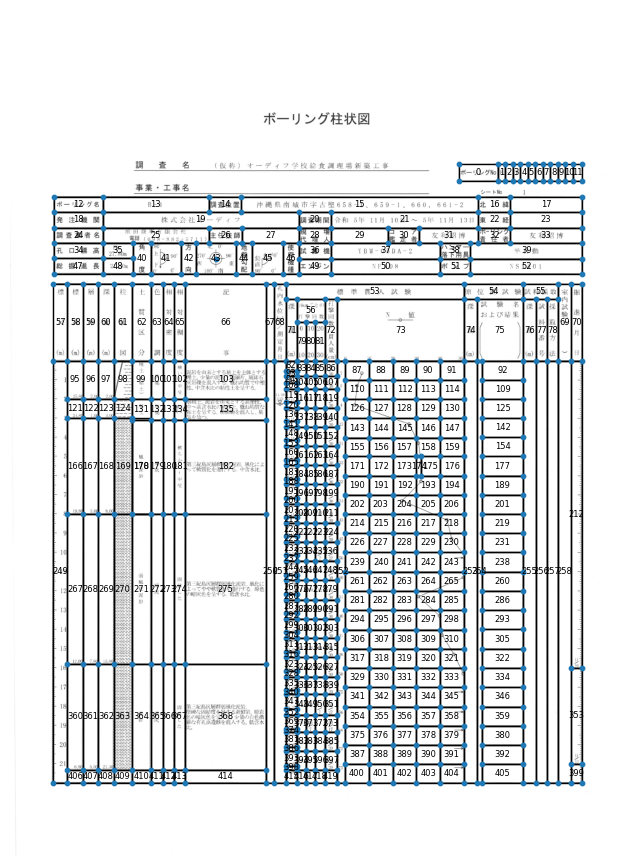

In [39]:
# img_path = "output/my_scan_p1.png"   # your borehole log image

img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Could not read image from: {img_path}")

# 1) Enhance lines
bw = enhance_lines(img)
# cv2.imwrite("debug_enhanced_lines.png", bw)

# 2) Extract lines
lines = extract_table_lines_from_binary(
    bw,
    scale_h=60,            # tweak if needed
    scale_v=60,
    min_line_length_h=20,  # shorter → more small grid lines
    min_line_length_v=20,
)

# from your extracted lines dict:
h4_raw = [(x1, y1, x2, y2) for (x1, y1), (x2, y2) in lines["horizontal"]]
v4_raw = [(x1, y1, x2, y2) for (x1, y1), (x2, y2) in lines["vertical"]]

# snap them to perfect H/V
h4_straight = straighten_lines(h4_raw, "h")
v4_straight = straighten_lines(v4_raw, "v")

# then detect cells
cells, intersections, newlines = detect_cells(
    h4_straight, v4_straight,
    tol_merge=2.0,          # controls merge gap_tol above if you pass it through
    tol_intersection=12.0,   # a bit looser
    tol_axis=12.0,
    tol_edge=12.0,
)
print("Detected cells:", len(cells))
print("Intersections:", len(intersections))

ordered_cells = sort_cells_row_major(cells)

# 5) Visual checks
# plot_table_lines(img, lines, figsize=(8, 11))
# plot_table_lines(img, newlines, figsize=(8, 11))
plot_cells_and_points(img, ordered_cells, intersections, figsize=(8, 11))


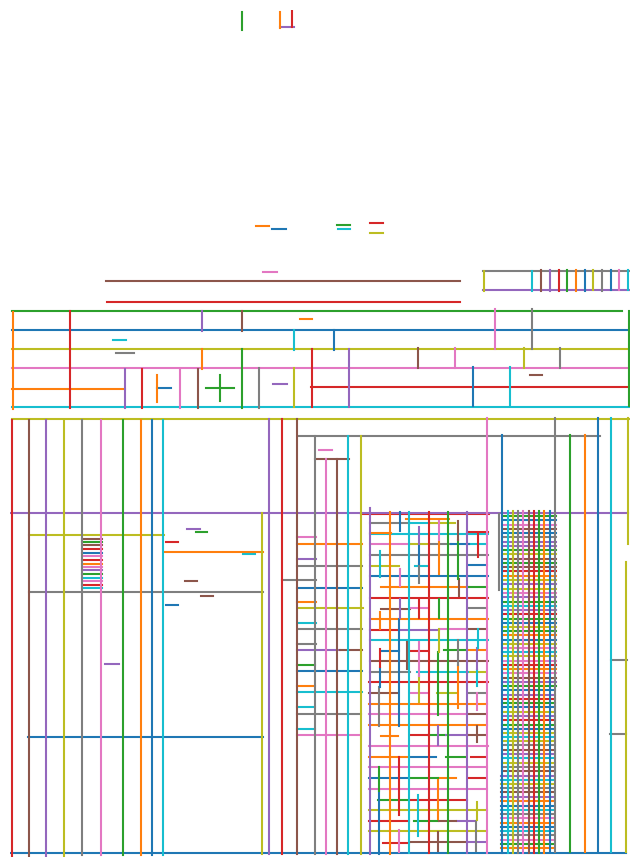

In [24]:
plot_table_lines(None, lines, figsize=(8, 11))

In [40]:
metadata = {
    "borehole_no": 13,
    "location": 15,
    "north_latitude": 17,
    "east_longitude": 23, 
    "client": 19,
    "investigation_period": 21,
    "contractor": 25,
    "chief_engineer": 27,
    "representative": 29,
    "inspector": 31,
    "supervisor": 33,
    "collar_elevation_el_m": 35,
    "total_depth_m": 48,
    "drilling_machine": 37,
    "engine": 50,
    "hammer_device": 39,
    "pump": 52
}

columns_data = {
    # "height_m": 58,
    "soil_depth_m": 60,
    "soil_classification": 62,
    "color": 63,
    # "relative_density": 64,
    "relative_consistency": 65,
    "description": 66,
    # "water_record": 68,
    "depth": 71,
    "0-10": 79,
    "10-20": 80,
    "20-30": 81,
    # "total": 72,
}

In [41]:
def per10(text: str):
    if text == "":
        return {"count": "0", "penetration": "0"}
    items = text.split("\n")
    if len(items) > 1:
        pene = ""
        for it in items[1:]:
            if it == "/":
                continue
            pene = it
        return  {"count": items[0], "penetration": pene}
    else:
        return {"count": items[0], "penetration": "10"}
    
def parse_json(boring_result: dict, output_name: str = "boring_log_output.json"):
    final_result = {}
    for key in metadata:
        final_result[key] = boring_result[key]

    # water_record = boring_result["water_record"][0].split("\n")
    # if len(water_record) > 1:
    #     final_result["water_record"] = {"level": water_record[1], "date": water_record[0]}
    # else:
    #     final_result["water_record"] = water_record[0]
    states = []
    for i in range(len(boring_result["soil_depth_m"])):
        row = {}
        # for col in ["height_m", "soil_depth_m", "soil_classification", "color", "relative_density",
        #             "relative_consistency", "description"]:
        for col in ["soil_depth_m", "soil_classification", "color",
                    "relative_consistency", "description"]:
            row[col] = "".join(boring_result[col][i].split("\n"))
        # if (row["height_m"] == "" and row["soil_depth_m"] == "" and row["soil_classification"] == "" and
        #     row["color"] == "" and row["relative_density"] == "" and row["relative_consistency"] == "" and
        #     row["description"] == ""):
        if (row["soil_depth_m"] == "" and row["soil_classification"] == "" and
            row["color"] == "" and row["relative_consistency"] == "" and
            row["description"] == ""):
            continue
        states.append(row)
    final_result["soi_layers"] = states
    depth = []
    for d in boring_result["depth"]:
        if d == "":
            continue
        items = d.split("\n")
        depth += items
    spt = []
    for i in range(len(depth)//2):
        row = {}
        row["depth"] = {"start": depth[2*i], "end": depth[2*i+1]}
        row["blow_counts_0_10cm"] = per10(boring_result["0-10"][i])
        row["blow_counts_10_20cm"] = per10(boring_result["10-20"][i])
        row["blow_counts_20_30cm"] = per10(boring_result["20-30"][i])
        # row["total"] = per10(boring_result["total"][i])
        spt.append(row)
    final_result["spt_tests"] = spt

    json.dump(final_result, open(output_name, "w", encoding="utf-8"), ensure_ascii=False, indent=2)
    return final_result

In [30]:
def denorm_point(x_norm: float, y_norm: float,
                 img_width: int, img_height: int,
                 scale: float = 1000.0):
    """
    Convert normalized (0..scale) coords to pixel coords.

    x_norm, y_norm: coordinates in [0, scale]
    img_width, img_height: image size in pixels
    """
    x_px = x_norm / scale * (img_width  - 1)
    y_px = y_norm / scale * (img_height - 1)
    return x_px, y_px

In [36]:
label = 135
bbox = ordered_cells[label]

bbox = [2280, 280, 2340, 350]

# From file
crop = crop_image_file(img_path, bbox, margin=1,output_path="crop_test.png")

In [96]:
header_idx = 66 # for example
col_indices = find_column(ordered_cells, header_idx)
print(col_indices)

# Get the actual cell bboxes if needed
# column_cells = [ordered_cells[i] for i in col_indices]

[66, 103, 135, 182, 275, 368, 414]


In [19]:
# bits = []
# for idx in col_indices[1:]:
#     bbox = ordered_cells[idx]
#     crop = crop_image_file(img_path, bbox, margin=1)
#     bit = image_array_to_png_bytes(crop)
#     bits.append(bit)

# result = transform_images_to_json(images=bits, instruction_path="boring_log_instructions_image.txt")
# print(result)

In [20]:
bits = []
boring_result = {}

print("Extracting metadata fields...")
for meta in metadata:
    field_idx = metadata[meta]
    bbox = ordered_cells[field_idx]
    crop = crop_image_file(img_path, bbox, margin=1)
    bit = image_array_to_png_bytes(crop)
    bits.append(bit)

result = transform_images_to_json(images=bits, instruction_path="boring_log_instructions_image.txt")
for key, value in zip(list(metadata.keys()), result["result"]):
    boring_result[key] = value

print("Complete extracting metadata fields!")
print("Extracting columns fields...")
for col in columns_data:
    print(col)
    header_idx = columns_data[col]  # for example
    col_indices = find_column(ordered_cells, header_idx)
    bits = []
    for idx in col_indices[1:]:
        bbox = ordered_cells[idx]
        crop = crop_image_file(img_path, bbox, margin=1)
        bit = image_array_to_png_bytes(crop)
        bits.append(bit)
    result = transform_images_to_json(images=bits, instruction_path="boring_log_instructions_image.txt")
    boring_result[col] = result["result"]

bbox = ordered_cells[72]
founded = []
for cell in ordered_cells[72:]:
    if cell[0] == bbox[2] and cell[1] == bbox[3]:
        founded = cell
        break
if founded:
    bit = crop_image_file(img_path, founded, margin=1)
    bit = image_array_to_png_bytes(bit)
    result = transform_images_to_json(images=[bit], instruction_path="boring_log_instructions_image.txt")
    boring_result["n_value"] = result["result"][0]

print("Complete extracting columns fields!")

Extracting metadata fields...
Complete extracting metadata fields!
Extracting columns fields...
height_m
soil_depth_m
soil_classification
color
relative_density
relative_consistency
description
water_record
depth
0-10
10-20
20-30
Complete extracting columns fields!


In [21]:
print(boring_result)

{'borehole_no': 'B-1', 'location': '沖縄県 南城市字古堅658-1、659-1、660、661-2', 'north_latitude': '', 'east_longitude': '', 'client': '株式会社オーデ ィフ', 'investigation_period': '令和 5年 11月 10日 ～ 5年 11月 13日', 'contractor': '前田 商 事 有限 会社\n電話 (098-882-5711)', 'chief_engineer': '', 'representative': '', 'inspector': '友利 昭 博', 'supervisor': '友利 昭 博', 'collar_elevation_el_m': 'EL.\n27.80m', 'total_depth_m': '21.30m', 'drilling_machine': 'YB M-05D A-2', 'engine': 'N F A D 8', 'hammer_device': '半自動', 'pump': 'N S X 4 0 1', 'height_m': ['25.80', '24.80', '19.80', '12.00', '6.50', ''], 'soil_depth_m': ['2.00', '3.00', '8.00', '15.80', '21.30', ''], 'soil_classification': ['埋\n土\n(粘\n土)', '粘\n土', '風\n化\n泥\n岩', '弱\n風\n化\n泥\n岩', '泥\n岩', ''], 'color': ['灰\n褐', '灰\n褐', '褐\n灰', '暗\n灰', '暗\n灰', ''], 'relative_density': ['', '', '', '', '', ''], 'relative_consistency': ['硬い\n～\n中\n位', '軟らい', '軟らかい\n中\n位', '固結した', '固結した', ''], 'description': ['泥岩を由来とする粘土を主体とする\n埋土。少量の泥岩土塊細片、硫球石\n灰岩礫を混入する。概ね均質で中塑\n性、中含水比の粘性土を呈する。', '崩積土。

In [22]:
parse_json(boring_result, "boring_log_output.json")

{'borehole_no': 'B-1',
 'location': '沖縄県 南城市字古堅658-1、659-1、660、661-2',
 'north_latitude': '',
 'east_longitude': '',
 'client': '株式会社オーデ ィフ',
 'investigation_period': '令和 5年 11月 10日 ～ 5年 11月 13日',
 'contractor': '前田 商 事 有限 会社\n電話 (098-882-5711)',
 'chief_engineer': '',
 'representative': '',
 'inspector': '友利 昭 博',
 'supervisor': '友利 昭 博',
 'collar_elevation_el_m': 'EL.\n27.80m',
 'total_depth_m': '21.30m',
 'drilling_machine': 'YB M-05D A-2',
 'engine': 'N F A D 8',
 'hammer_device': '半自動',
 'pump': 'N S X 4 0 1',
 'water_record': {'level': '2.23', 'date': '11/16'},
 'soi_layers': [{'height_m': '25.80',
   'soil_depth_m': '2.00',
   'soil_classification': '埋土(粘土)',
   'color': '灰褐',
   'relative_density': '',
   'relative_consistency': '硬い～中位',
   'description': '泥岩を由来とする粘土を主体とする埋土。少量の泥岩土塊細片、硫球石灰岩礫を混入する。概ね均質で中塑性、中含水比の粘性土を呈する。'},
  {'height_m': '24.80',
   'soil_depth_m': '3.00',
   'soil_classification': '粘土',
   'color': '灰褐',
   'relative_density': '',
   'relative_consistency': '軟ら

In [ ]:
# final_result = {}
# for key in metadata:
#     final_result[key] = boring_result[key]

# water_record = boring_result["water_record"][0].split("\n")
# if len(water_record) > 1:
#     final_result["water_record"] = {"level": water_record[1], "date": water_record[0]}
# else:
#     final_result["water_record"] = water_record[0]
# states = []
# for i in range(len(boring_result["height_m"])):
#     row = {}
#     for col in ["height_m", "soil_depth_m", "soil_classification", "color", "relative_density",
#                 "relative_consistency", "description"]:
#         row[col] = "".join(boring_result[col][i].split("\n"))
#     if (row["height_m"] == "" and row["soil_depth_m"] == "" and row["soil_classification"] == "" and
#         row["color"] == "" and row["relative_density"] == "" and row["relative_consistency"] == "" and
#         row["description"] == ""):
#         continue
#     states.append(row)
# final_result["soi_layers"] = states
# depth = []
# for d in boring_result["depth"]:
#     if d == "":
#         continue
#     items = d.split("\n")
#     depth += items

# n_value = boring_result["n_value"].split("\n")
# spt = []
# for i in range(len(n_value)):
#     row = {}
#     row["depth"] = {"start": depth[2*i], "end": depth[2*i+1]}
#     row["blow_counts_0_10cm"] = per10(boring_result["0-10"][i])
#     row["blow_counts_10_20cm"] = per10(boring_result["10-20"][i])
#     row["blow_counts_20_30cm"] = per10(boring_result["20-30"][i])
    
#     row["n_value"] = n_value[i]
#     spt.append(row)
# final_result["spt_tests"] = spt

# json.dump(final_result, open("boring_log_result_1.json", "w", encoding="utf-8"), ensure_ascii=False, indent=2)

In [16]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def process_boring_log(img_path, metadata, columns_data, ordered_cells):
    boring_result = {}

    # -----------------------------
    # 1) Prepare all jobs
    # -----------------------------
    jobs = []  # each job: (kind, payload, extra_info)

    # --- metadata job ---
    meta_bits = []
    meta_keys = list(metadata.keys())

    print("Preparing metadata fields...")
    for meta_key in meta_keys:
        field_idx = metadata[meta_key]
        bbox = ordered_cells[field_idx]
        crop = crop_image_file(img_path, bbox, margin=1)
        bit = image_array_to_png_bytes(crop)
        meta_bits.append(bit)

    jobs.append((
        "metadata",  # kind
        meta_bits,   # images
        {"meta_keys": meta_keys},
    ))

    # --- columns jobs ---
    print("Preparing columns fields...")
    for col in columns_data:
        print("  column:", col)
        header_idx = columns_data[col]
        col_indices = find_column(ordered_cells, header_idx)

        col_bits = []
        for idx in col_indices[1:]:
            bbox = ordered_cells[idx]
            crop = crop_image_file(img_path, bbox, margin=1)
            bit = image_array_to_png_bytes(crop)
            col_bits.append(bit)

        jobs.append((
            "column",
            col_bits,
            {"col_name": col},
        ))

    # -----------------------------
    # 2) Fire all Gemini requests in parallel
    # -----------------------------
    instruction_path = "boring_log_instructions_image.txt"

    def run_job(kind, bits, extra):
        # 1 LLM call per job
        result = transform_images_to_json(
            images=bits,
            instruction_path=instruction_path,
        )
        return kind, result, extra

    # token usage accumulators
    total_input_tokens = 0
    total_output_tokens = 0
    total_tokens = 0

    # max_workers: how many requests in flight at once
    with ThreadPoolExecutor(max_workers=14) as executor:
        future_to_job = {
            executor.submit(run_job, kind, bits, extra): (kind, extra)
            for (kind, bits, extra) in jobs
        }

        # As each completes, fill boring_result
        for future in as_completed(future_to_job):
            kind, extra = future_to_job[future]
            try:
                kind_ret, result, extra_ret = future.result()
            except Exception as e:
                print(f"[ERROR] Job {kind} failed: {e}")
                continue

            # --- accumulate token usage ---
            usage = result.get("_usage") if isinstance(result, dict) else None
            if usage:
                # .get(..., 0) handles None
                in_tok = usage.get("input_tokens") or 0
                out_tok = usage.get("output_tokens") or 0
                tot_tok = usage.get("total_tokens") or 0

                total_input_tokens += in_tok
                total_output_tokens += out_tok
                total_tokens += tot_tok

            # --- parse result payload ---
            # result["result"] is your list of strings
            if kind_ret == "metadata":
                meta_keys = extra_ret["meta_keys"]
                for key, value in zip(meta_keys, result["result"]):
                    boring_result[key] = value

            elif kind_ret == "column":
                col_name = extra_ret["col_name"]
                boring_result[col_name] = result["result"]

    # -----------------------------
    # 3) Print total token usage
    # -----------------------------
    print(
        f"Total token usage for this boring log: "
        f"input={total_input_tokens}, "
        f"output={total_output_tokens}, "
        f"total={total_tokens}"
    )

    print("All fields extracted.")
    return boring_result


In [19]:
boring_result = process_boring_log(img_path, metadata, columns_data, ordered_cells)
final_result = parse_json(boring_result, "boring_log_output_parallel_p3.json")

Preparing metadata fields...
Preparing columns fields...
  column: soil_depth_m
  column: soil_classification
  column: color
  column: relative_consistency
  column: description
  column: depth
  column: 0-10
  column: 10-20
  column: 20-30
Total token usage for this boring log: input=47488, output=1718, total=55800
All fields extracted.


In [20]:
print(boring_result)

{'soil_depth_m': ['2.00', '3.00', '8.00', '15.80', '21.30', ''], 'color': ['灰\n褐', '灰\n褐', '褐\n灰', '暗\n灰', '暗\n灰', ''], 'soil_classification': ['埋土\n(\n粘土\n)', '粘土', '風化\n泥岩', '弱\n風化\n泥岩', '泥\n岩', ''], 'relative_consistency': ['硬い\n~\n中\n位', '軟らかい', '軟らかい\n中\n位', '固\n結\nした', '固\n結\nした', ''], 'description': ['泥岩を由来とする粘土を主体とする\n埋土。少量の泥岩土塊細片、琉球石\n灰岩礫を混入する。概ね均質で中塑\n性、中含水比の粘性土を呈する。', '崩積土。泥岩を由来とする高塑性、\n中~高含水比の粘性土。概ね均質な\n粘土を呈する。腐植物を混入し、臭\n気を放つ。', '第三紀島尻層群風化泥岩。風化によ\nって軟質化を進行する。中含水比。', '第三紀島尻層群弱風化泥岩。風化に\nよってやや軟質化を進行する。原色\nの暗灰色を呈する。低含水比。', '第三紀島尻層群弱風化泥岩。\n堅硬な固結度を呈する新鮮岩。原岩\n色の暗灰色を呈する。少量の白色微\n細な有孔虫遺骸を混入する。低含水\n比。', ''], '0-10': ['2', '2', '2', '7', '8', '9', '9', '8', '10', '13', '14', '15', '9', '12', '12', '11', '11', '24', '14', '25', '21', '19', ''], '10-20': ['2', '2', '1', '8', '11', '11', '11', '7', '16', '15', '20', '17', '10', '13', '13', '16', '19', '26', '23', '25\n/\n7', '29', '31', ''], '20-30': ['3', '1', '1', '12', '12', '12', '12', '9', '17', '17', '16\n/\n7', '18', '12', '15', '1